# MAIQMag Benchmark
## Hierarchical vs Flat × JSONB vs Native Columns

This notebook visualises the results of the benchmark comparing:

| | Hierarchical (3 tables) | Flat (1 table) |
|---|---|---|
| **Native columns** | Schema A | Schema B |
| **JSONB metadata** | Schema C | Schema D |

**File structure**
```
benchmark/
├── sql/
│   ├── schema_a.sql          # Hierarchical + Native columns
│   ├── schema_b.sql          # Flat + Native columns
│   ├── schema_c.sql          # Hierarchical + JSONB (current design)
│   └── schema_d.sql          # Flat + JSONB (control cell)
├── generate_data.py          # Synthetic data generator and DB populator
├── benchmark_runner.py       # Query runner, timing, EXPLAIN capture
├── benchmark_analysis.ipynb  # Jupyter notebook with all plots
└── results/                  # Created automatically
    ├── benchmark_results.csv
    ├── summary_statistics.csv
    └──explain_plans/        # One .txt per (query, schema, scale)
```

**Axes of comparison:**
- Query latency of every schemas at all scales. 
- Evolution of query latency for increasing data volume.
- Storage footprint 

# 1. List of queries to compare our different data schemas

| Query | Description | Example | What it tests |
|-------|-------------|---------|---------------|
| Q1 | Entity-level filter |"Find all entities where `ja_mev > 5.0` "| Single-level filter, index selectivity |
| Q2 | Cross-level filter | "Find all entities from material NiPS3 with spin_s>1" | Join cost vs deduplication cost |
| Q3 | Aggregation | "Count entities per dataset" | COUNT vs COUNT DISTINCT at scale |
| Q4 | Artifact retrieval | "Get all artifacts for entity H_636ce3e4"| Flat schema's best case |
| Q5 | Dataset-level metadata update | "Update the facility for dataset RIXS from LCLS 1 to LCLS 2"| Write amplification |
| Q6 | JSONB range scan |"Find all entities where any metadata field contains a value in a specific range"| GIN index + cast performance (C, D only) |
| Q7 | Insert new entity with artifacts | "Insert a new entity with 10 artifacts into the VDP dataset" | Write overhead, row fanout |

# 2.  Data Scales

| Scale  | Entities | Artifacts/entity | Total rows (flat) |
|--------|----------|------------------|-------------------|
| Small  | 100      | 10               | ~6,000            |
| Medium | 1,000    | 10               | ~60,000           |
| Large  | 10,000   | 50               | ~3,000,000        |

# 3. Results and observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
SCHEMA_COLORS = {
    'A': '#2196F3',   # blue  – hierarchical + native
    'B': '#4CAF50',   # green – flat + native
    'C': '#FF9800',   # orange – hierarchical + JSONB (current)
    'D': '#E91E63',   # pink  – flat + JSONB
}
SCHEMA_LABELS = {
    'A': 'A – Hier+Native',
    'B': 'B – Flat+Native',
    'C': 'C – Hier+JSONB (current)',
    'D': 'D – Flat+JSONB',
}
SCALE_ORDER = ['small', 'medium', 'large']

# ── Load results ───────────────────────────────────────────────────────────
CSV_PATH = Path('results/benchmark_results.csv')

if not CSV_PATH.exists():
    print(f'⚠  {CSV_PATH} not found.')
    print('Run benchmark_runner.py first, or point CSV_PATH to your results file.')
    # Create a synthetic demo dataset so the notebook renders anyway
    import random, itertools
    random.seed(0)
    rows = []
    rows2=[]
    queries = ['Q1_entity_filter','Q2_cross_level_filter','Q3_aggregation',
               'Q4_artifact_retrieval','Q5_dataset_update','Q6_jsonb_range_scan','Q7_insert']
    base = {'A':2,'B':1.5,'C':4,'D':3}  # relative base ms per schema
    scale_mult = {'small':1,'medium':8,'large':120}
    q_mult = {'Q1_entity_filter':1,'Q2_cross_level_filter':1.4,'Q3_aggregation':2.1,
               'Q4_artifact_retrieval':0.6,'Q5_dataset_update':1.8,'Q6_jsonb_range_scan':1.2,'Q7_insert':0.8}
    for q, s, sc in itertools.product(queries, ['A','B','C','D'], ['small','medium','large']):
        if q == 'Q6_jsonb_range_scan' and sc in ('A','B'):
            continue
        avg = base[s] * scale_mult[sc] * q_mult[q] * (1 + random.gauss(0, 0.1))
        rows.append({'query':q,'schema':sc,'scale':s,
                     'description':q.replace('_',' '),
                     'avg_ms':round(abs(avg),3),'stddev_ms':round(abs(avg)*0.05,3),
                     'min_ms':round(abs(avg)*0.9,3),'max_ms':round(abs(avg)*1.1,3),
                     'rows_returned':random.randint(50,5000),
                     'scan_type':random.choice(['Index Scan','Seq Scan','Hash Join']),
                     'table_size_mb':{'small':2,'medium':20,'large':400}[s] * (1 if sc in ('A','C') else 3)})
    df = pd.DataFrame(rows)
    print('  ➜  Using synthetic demo data for illustration.')
else:
    df = pd.read_csv(CSV_PATH)
    print(f'Loaded {len(df)} rows from {CSV_PATH}')

df['scale'] = pd.Categorical(df['scale'], categories=SCALE_ORDER, ordered=True)
df['schema_label'] = df['schema'].map(SCHEMA_LABELS)
df.head()

Loaded 78 rows from results/benchmark_results.csv


,query,schema,scale,description,avg_ms,stddev_ms,min_ms,max_ms,rows_returned,scan_type,table_size_mb,schema_label
0,Q1_entity_filter,A,small,Find all entities where Ja_mev > 5.0,0.213,0.024,0.184,0.255,43,Hash Join,0.531,A – Hier+Native
1,Q1_entity_filter,B,small,Find all entities where Ja_mev > 5.0,0.343,0.010,0.331,0.361,43,Aggregate,0.711,B – Flat+Native
2,Q1_entity_filter,C,small,Find all entities where Ja_mev > 5.0,0.221,0.009,0.208,0.233,43,Hash Join,0.750,C – Hier+JSONB (current)
3,Q1_entity_filter,D,small,Find all entities where Ja_mev > 5.0,0.538,0.004,0.532,0.545,43,Aggregate,2.164,D – Flat+JSONB
4,Q2_cross_level_filter,A,small,Find all entities from material NiPS3 with spi...,0.156,0.006,0.149,0.166,0,Nested Loop,0.531,A – Hier+Native


## 3. 1. Query runtime by schema and scale

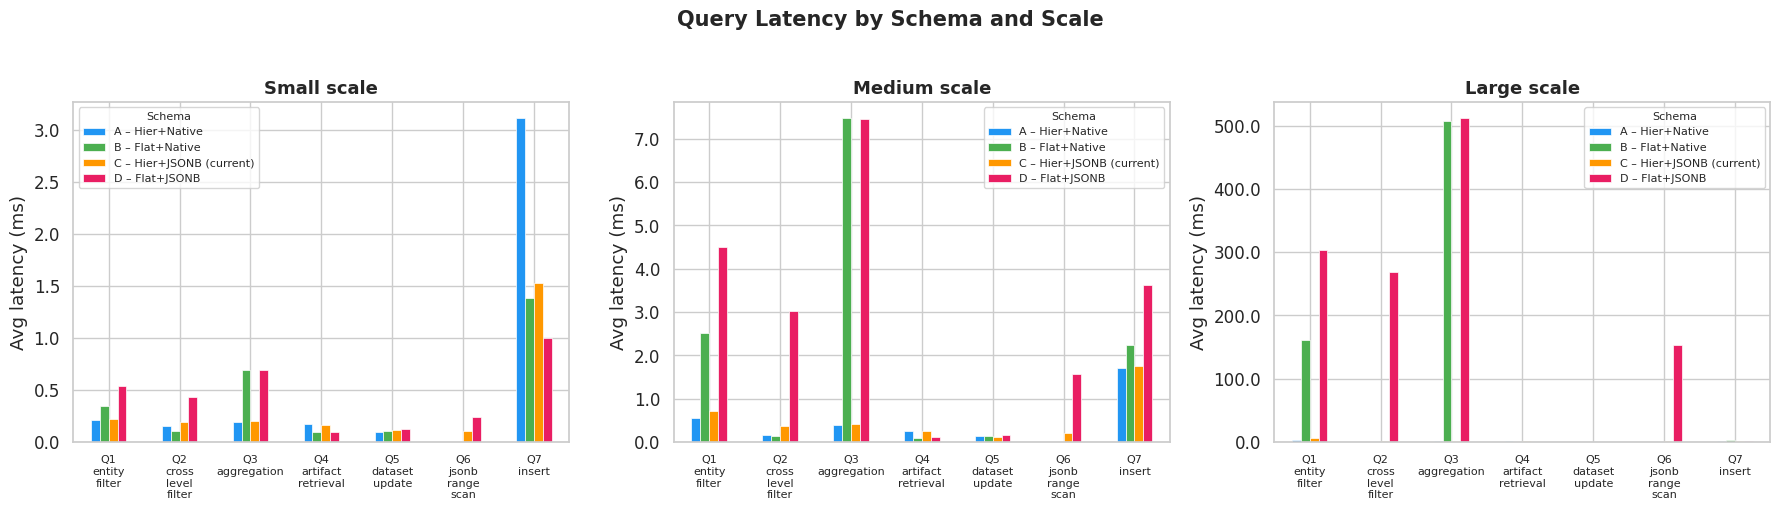

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, scale in zip(axes, SCALE_ORDER):
    sub = df[df['scale'] == scale].copy()

    if sub.empty:
        ax.set_title(f'{scale.capitalize()} scale (No data)', fontweight='bold', fontsize=13)
        ax.axis('off')  
        continue

    pivot = sub.pivot_table(index='query', columns='schema', values='avg_ms', aggfunc='mean')
    pivot = pivot.reindex(columns=['A', 'B', 'C', 'D'])
    pivot.plot(kind='bar', ax=ax,
               color=[SCHEMA_COLORS[s] for s in pivot.columns],
               edgecolor='white', linewidth=0.5)
    ax.set_title(f'{scale.capitalize()} scale', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Avg latency (ms)')
    ax.set_xticklabels([q.replace('_', ' ').replace(' ', '\n') for q in pivot.index],
                       rotation=0, fontsize=8)
    ax.legend(title='Schema', labels=[SCHEMA_LABELS[s] for s in pivot.columns],
              fontsize=8, title_fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.suptitle('Query Latency by Schema and Scale', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/01_overview_by_scale.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Only small scale
small_df = df[df['scale'] == 'small'].copy()

pivot_small = small_df.pivot_table(index='query', columns='schema', values='avg_ms')
from IPython.display import display

print("Average runtime for large scale (ms):")
styled_table = pivot_small.style.format("{:.2f} ms").set_caption("Runtime for medium scale'")
display(styled_table)

Average runtime for large scale (ms):


schema,A,B,C,D
query,,,,
Q1_entity_filter,0.21 ms,0.34 ms,0.22 ms,0.54 ms
Q2_cross_level_filter,0.16 ms,0.10 ms,0.19 ms,0.43 ms
Q3_aggregation,0.20 ms,0.70 ms,0.20 ms,0.69 ms
Q4_artifact_retrieval,0.17 ms,0.10 ms,0.17 ms,0.10 ms
Q5_dataset_update,0.10 ms,0.11 ms,0.11 ms,0.12 ms
Q6_jsonb_range_scan,nan ms,nan ms,0.10 ms,0.24 ms
Q7_insert,3.12 ms,1.38 ms,1.53 ms,1.00 ms


In [4]:
# Only medium scale
medium_df = df[df['scale'] == 'medium'].copy()

pivot_medium = medium_df.pivot_table(index='query', columns='schema', values='avg_ms')
from IPython.display import display

print("Average runtime for large scale (ms):")
styled_table = pivot_medium.style.format("{:.2f} ms").set_caption("Runtime for medium scale'")
display(styled_table)

Average runtime for large scale (ms):


schema,A,B,C,D
query,,,,
Q1_entity_filter,0.55 ms,2.52 ms,0.71 ms,4.50 ms
Q2_cross_level_filter,0.15 ms,0.13 ms,0.36 ms,3.03 ms
Q3_aggregation,0.40 ms,7.48 ms,0.41 ms,7.44 ms
Q4_artifact_retrieval,0.25 ms,0.10 ms,0.25 ms,0.12 ms
Q5_dataset_update,0.13 ms,0.14 ms,0.11 ms,0.15 ms
Q6_jsonb_range_scan,nan ms,nan ms,0.21 ms,1.56 ms
Q7_insert,1.72 ms,2.24 ms,1.76 ms,3.62 ms


In [5]:
# Only large scale
large_df = df[df['scale'] == 'large'].copy()

pivot_large = large_df.pivot_table(index='query', columns='schema', values='avg_ms')
from IPython.display import display

print("Average runtime for large scale (ms):")
styled_table = pivot_large.style.format("{:.2f} ms").set_caption("Runtime for large scale'")
display(styled_table)

Average runtime for large scale (ms):


schema,A,B,C,D
query,,,,
Q1_entity_filter,3.55 ms,161.16 ms,5.62 ms,304.22 ms
Q2_cross_level_filter,0.15 ms,0.11 ms,2.02 ms,269.13 ms
Q3_aggregation,2.32 ms,506.76 ms,2.38 ms,512.32 ms
Q4_artifact_retrieval,0.80 ms,0.14 ms,0.83 ms,0.13 ms
Q5_dataset_update,0.10 ms,0.11 ms,0.11 ms,0.12 ms
Q6_jsonb_range_scan,nan ms,nan ms,1.03 ms,153.78 ms
Q7_insert,1.53 ms,2.80 ms,1.53 ms,1.07 ms


## 3. 2. Runtime vs. data volume per query

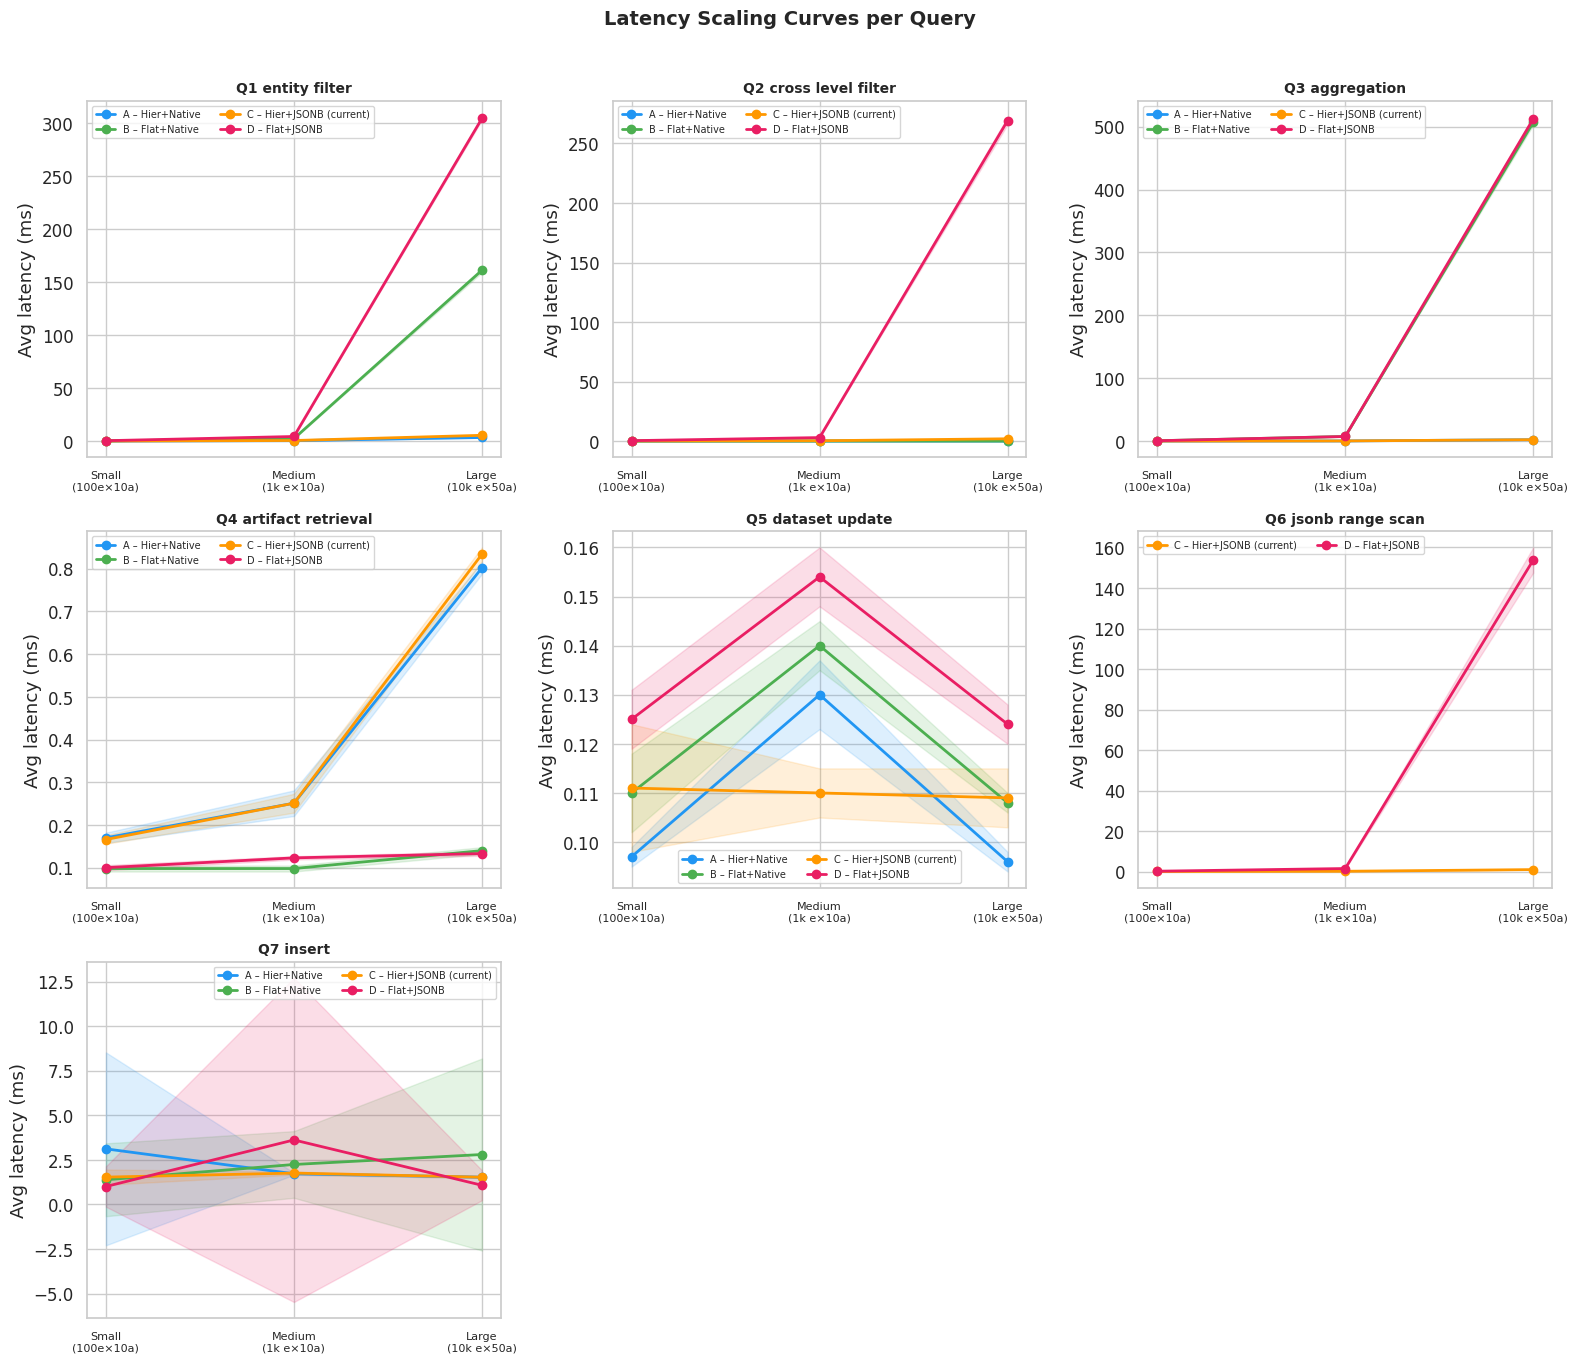

In [6]:
queries = df['query'].unique()
ncols = 3
nrows = int(np.ceil(len(queries) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = axes.flatten()

scale_x = {'small': 1, 'medium': 2, 'large': 3}
scale_labels = {1: 'Small\n(100e×10a)', 2: 'Medium\n(1k e×10a)', 3: 'Large\n(10k e×50a)'}

for ax, qname in zip(axes, queries):
    sub = df[df['query'] == qname]
    for schema in ['A','B','C','D']:
        s = sub[sub['schema'] == schema].sort_values('scale')
        if s.empty:
            continue
        xs = [scale_x[sc] for sc in s['scale'].astype(str)]
        ax.plot(xs, s['avg_ms'], marker='o', linewidth=2,
                color=SCHEMA_COLORS[schema], label=SCHEMA_LABELS[schema])
        ax.fill_between(xs,
                         s['avg_ms'] - s['stddev_ms'],
                         s['avg_ms'] + s['stddev_ms'],
                         alpha=0.15, color=SCHEMA_COLORS[schema])
    ax.set_title(qname.replace('_',' '), fontweight='bold', fontsize=10)
    ax.set_ylabel('Avg latency (ms)')
    ax.set_xticks([1,2,3])
    ax.set_xticklabels([scale_labels[x] for x in [1,2,3]], fontsize=8)
    ax.legend(fontsize=7, ncol=2)

# Hide unused axes
for ax in axes[len(queries):]:
    ax.set_visible(False)

plt.suptitle('Latency Scaling Curves per Query', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/02_scaling_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 3. Table sizes — storage amplification of the flat model

small | Schema B is 1.3× Schema A
small | Schema C is 1.4× Schema A
small | Schema D is 4.1× Schema A
medium | Schema B is 2.2× Schema A
medium | Schema C is 1.5× Schema A
medium | Schema D is 7.2× Schema A
large | Schema B is 2.6× Schema A
large | Schema C is 1.1× Schema A
large | Schema D is 4.6× Schema A


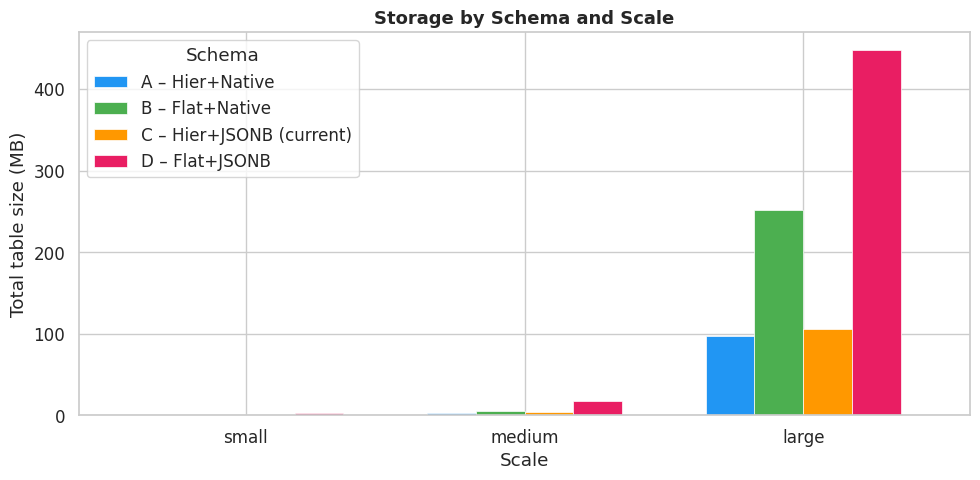

In [7]:
size_df = df.drop_duplicates(subset=['schema','scale'])[['schema','scale','table_size_mb']].copy()
size_df['scale'] = pd.Categorical(size_df['scale'], categories=SCALE_ORDER, ordered=True)
size_df = size_df.sort_values(['scale','schema'])

fig, ax = plt.subplots(figsize=(10, 5))
pivot_size = size_df.pivot(index='scale', columns='schema', values='table_size_mb')
pivot_size.plot(kind='bar', ax=ax, color=[SCHEMA_COLORS[s] for s in pivot_size.columns],
                edgecolor='white', linewidth=0.5, width=0.7)

ax.set_xlabel('Scale')
ax.set_ylabel('Total table size (MB)')
ax.set_title('Storage by Schema and Scale', fontweight='bold', fontsize=13)
ax.set_xticklabels(SCALE_ORDER, rotation=0)
ax.legend(title='Schema', labels=[SCHEMA_LABELS[s] for s in pivot_size.columns])

# Annotate amplification ratio vs Schema A
for scale in SCALE_ORDER:
    row = pivot_size.loc[scale]
    baseline = row.get('A', 1)
    for schema in ['B','C','D']:
        if schema in row and baseline > 0:
            ratio = row[schema] / baseline
            print(f'{scale} | Schema {schema} is {ratio:.1f}× Schema A')

plt.tight_layout()
plt.savefig('results/04_table_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 4. Comparison of the flat vs hierarchical and Native columns vs JSONB

- **Join cost for Native Columns** = `time(A) - time(B)` (same native columns, hierarchical vs flat)
- **Join cost for JSONB** = `time(C) - time(D)` (JSONB, hierarchical vs flat)
- **JSONB cost** = `time(C) - time(A)` (same hierarchy, JSONB vs native)`

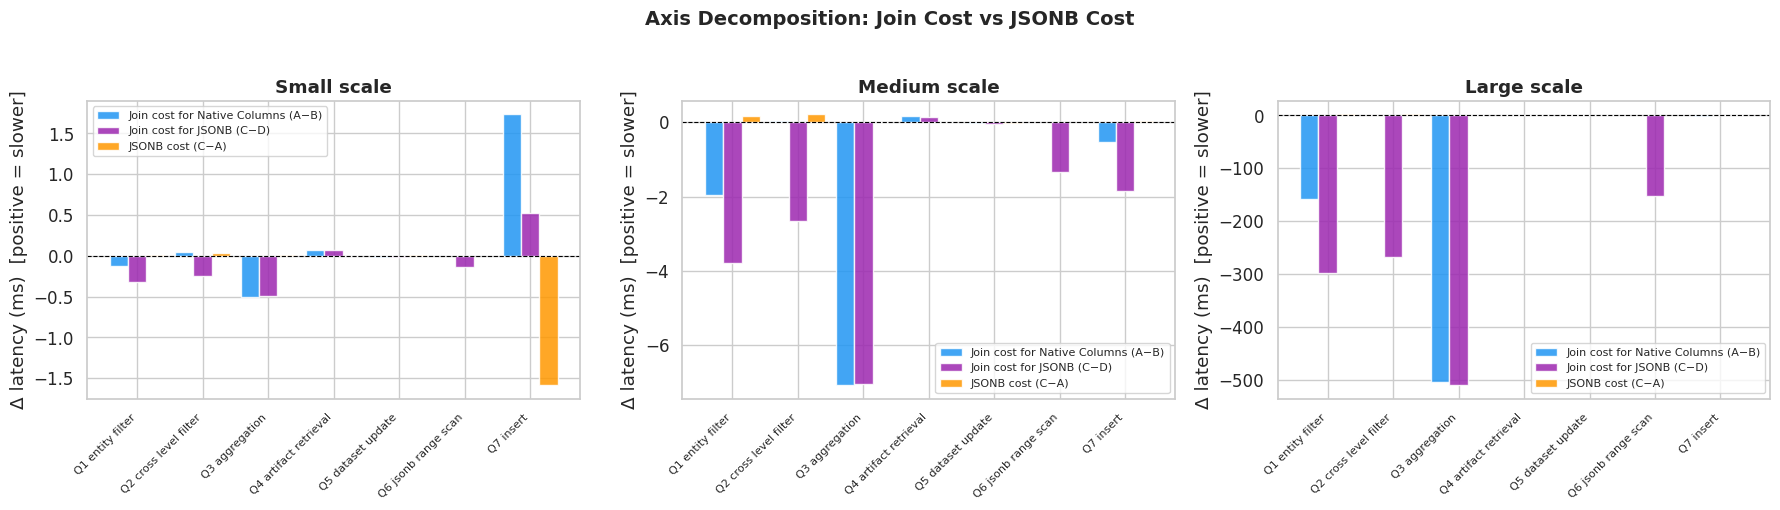

In [8]:
pivot_all = df.pivot_table(index=['query','scale'], columns='schema', values='avg_ms').reset_index()

pivot_all['join_cost__JSON_ms']    = pivot_all['A'] - pivot_all['B']   # hierarchical penalty
pivot_all['join_cost_JSONB_ms']    = pivot_all['C'] - pivot_all['D']   # hierarchical penalty
pivot_all['jsonb_cost_ms']   = pivot_all['C'] - pivot_all['A']   # JSONB penalty


scales_to_plot = df['scale'].cat.categories

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, scale in zip(axes, scales_to_plot):
    sub = pivot_all[pivot_all['scale'] == scale].copy()
    x = np.arange(len(sub))
    width = 0.28
    ax.bar(x - width, sub['join_cost__JSON_ms'],   width, label='Join cost for Native Columns (A−B)',   color='#2196F3', alpha=0.85)
    ax.bar(x ,  sub['join_cost_JSONB_ms'], width, label='Join cost for JSONB (C−D)', color='#9C27B0', alpha=0.85)
    ax.bar(x+ width,          sub['jsonb_cost_ms'],  width, label='JSONB cost (C−A)',  color='#FF9800', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{scale.capitalize()} scale', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['query'].str.replace('_',' '), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Δ latency (ms)  [positive = slower]')
    ax.legend(fontsize=8)

plt.suptitle('Axis Decomposition: Join Cost vs JSONB Cost', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/03_axis_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 5. Heatmap — latency matrix (queries × schemas) at all scales

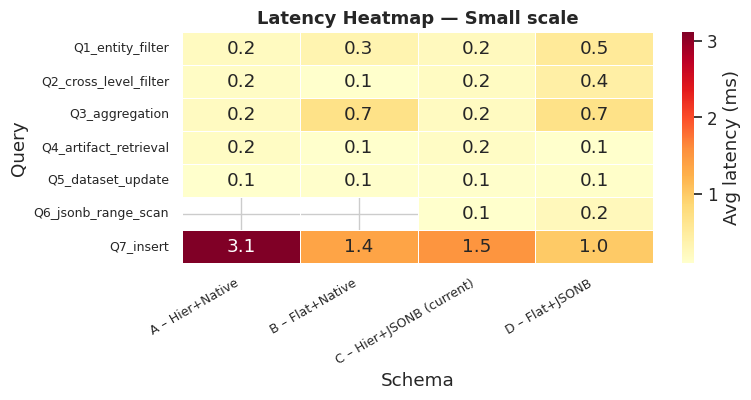

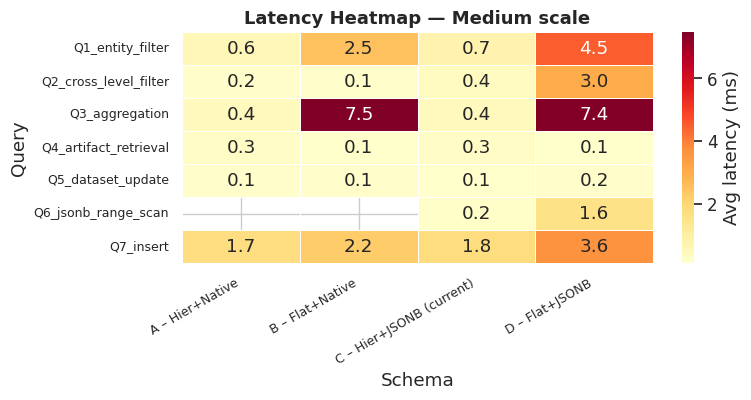

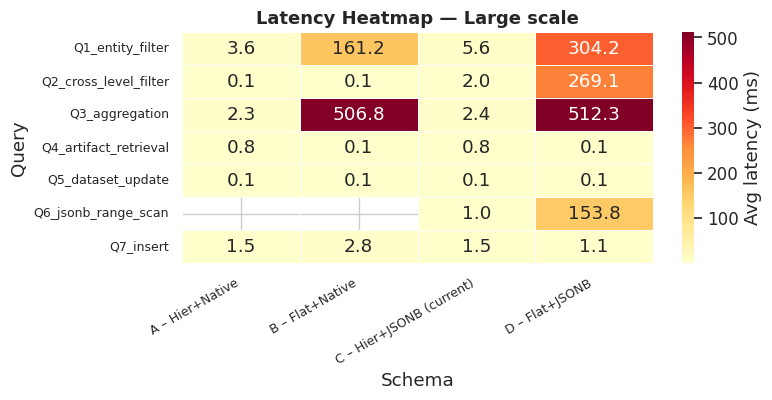

In [9]:
for scale in SCALE_ORDER:
    sub = df[df['scale'] == scale]
    heat = sub.pivot_table(index='query', columns='schema', values='avg_ms', aggfunc='mean')
    heat = heat.reindex(columns=['A','B','C','D'])

    fig, ax = plt.subplots(figsize=(8, max(4, len(heat) * 0.6)))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Avg latency (ms)'})
    ax.set_title(f'Latency Heatmap — {scale.capitalize()} scale', fontweight='bold', fontsize=13)
    ax.set_xlabel('Schema')
    ax.set_ylabel('Query')
    ax.set_xticklabels([SCHEMA_LABELS[s] for s in ['A','B','C','D']], rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'results/05_heatmap_{scale}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3.6. Scan type distribution — Index vs Seq scans

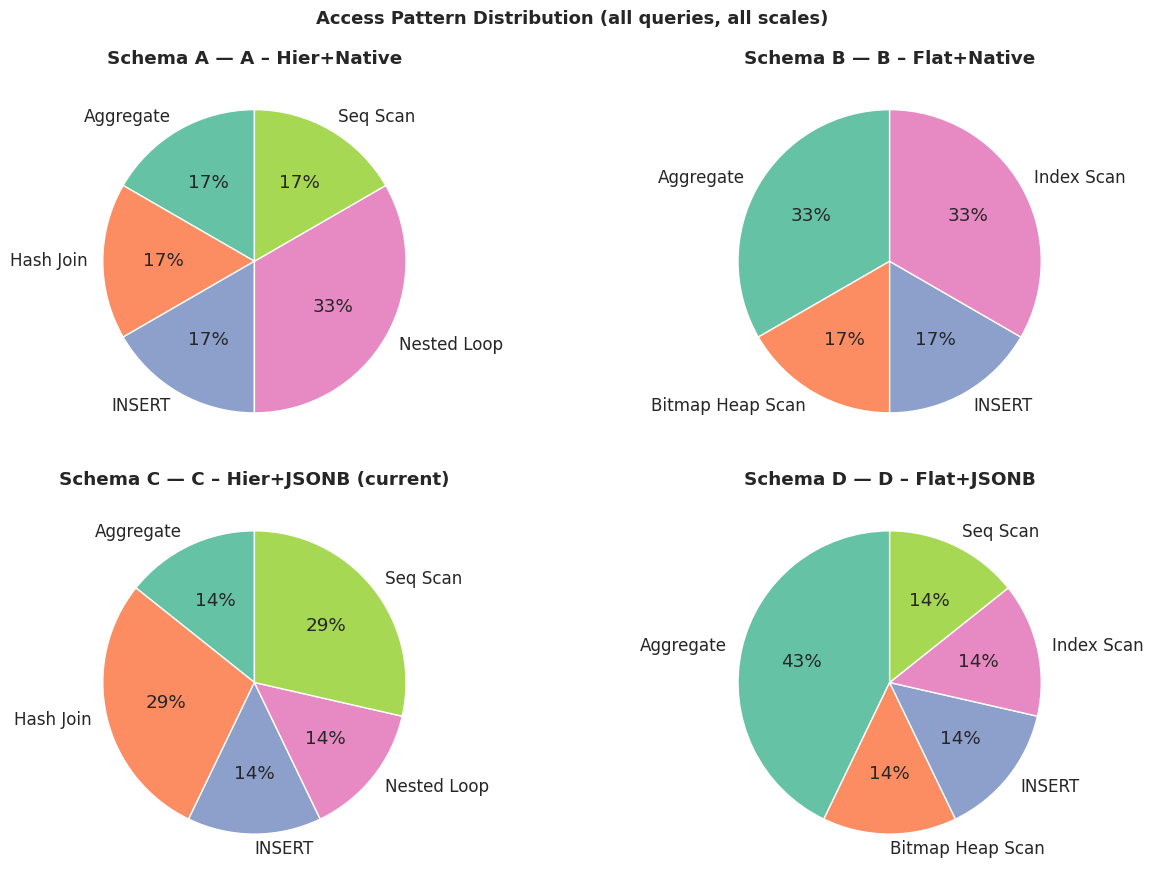

In [10]:
scan_counts = df.groupby(['schema','scan_type']).size().reset_index(name='count')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, schema in zip(axes.flatten(), ['A','B','C','D']):
    sub = scan_counts[scan_counts['schema'] == schema]
    if sub.empty:
        ax.set_visible(False)
        continue
    wedges, texts, autotexts = ax.pie(
        sub['count'], labels=sub['scan_type'], autopct='%1.0f%%',
        startangle=90, colors=sns.color_palette('Set2', len(sub))
    )
    ax.set_title(f'Schema {schema} — {SCHEMA_LABELS[schema]}', fontweight='bold')

plt.suptitle('Access Pattern Distribution (all queries, all scales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/08_scan_type_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Interpretation summary

### Query Performance by Schema

1. **Schema A — Hierarchical + Native Columns**
   - **Strengths**:
     - Best overall performance on filtered queries (Q1, Q2) at all scales — join cost is negligible when indexes are used effectively
     - Most storage-efficient schema — no metadata duplication
     - Clean typed columns enable fast numeric comparisons without casting overhead
   - **Weaknesses**:
     - Join cost becomes visible at large scale on Q4 (artifact retrieval) — latency reaches ~0.8ms vs ~0.13ms for flat schemas
   - **Best For**: Read-heavy workloads with well-defined, stable param schemas

2. **Schema B — Flat + Native Columns**
   - **Strengths**:
     - Dominates on Q4 (artifact retrieval) — stays flat at ~0.13ms even at large scale while hierarchical schemas reach ~0.8ms
     - No join overhead — single table scan for all queries
     - Best scan type distribution — highest proportion of Index Scans
   - **Weaknesses**:
     - Largest storage footprint — dataset and entity metadata repeated for every artifact row
     - Q3 (aggregation) requires `COUNT(DISTINCT entity_name)` which is significantly slower than `COUNT(*)` on the hierarchical schema at large scale (~500ms vs ~5ms)
     - Write amplification on dataset-level updates (Q5) — touches N×M rows instead of 1
     - No flexibility for heterogeneous metadata — all 6 datasets must share the same column superset
   - **Best For**: Artifact-centric read workloads where Q4-type lookups dominate

3. **Schema C — Hierarchical + JSONB** 
   - **Strengths**:
     - Nearly identical to Schema A on most queries — JSONB overhead is minimal with expression indexes
     - Naturally handles schema heterogeneity — VDP entities store `{Ja_mev, spin_s}`, EDRIXS entities store `{Udd, Delta, crystal_10Dq}` without NULL columns
     - Single-row dataset updates (Q5) — no write amplification
     - Most storage-efficient after Schema A
     - GIN indexes enable fast containment queries (`@>`) that have no equivalent in native schemas
   - **Weaknesses**:
     - Q4 (artifact retrieval) is slower due to the hierarchical structure.  
     - Slightly more complex query syntax (`meta->>'Ja_mev')::float` vs `Ja_mev`)
   - **Best For**: The MAIQMag catalog — heterogeneous params across datasets, moderate read/write mix, need for schema flexibility as new datasets are onboarded

4. **Schema D — Flat + JSONB**
   - **Strengths**:
     - Combines flat structure with JSONB flexibility
     - Matches Schema B on Q4 at small/medium scale
   - **Weaknesses**:
     - Worst performance at large scale on Q1, Q2, Q3, Q6 — combines the storage overhead of flat schemas with the processing overhead of JSONB
     - Q1 reaches ~305ms and Q6 reaches ~155ms at large scale — 10-50× slower than Schema C on the same queries
     - Largest storage footprint — JSONB blobs repeated for every artifact row
     - 43% Aggregate scan distribution indicates frequent full-table operations
   - **Best For**: Control cell for benchmarking — not recommended for production

---

### Conclusion

While each schema has its strengths and weaknesses, **Schema C (Hierarchical + JSONB)** emerges as the best overall choice for most applications. It strikes a balance between:
- **Performance**: Reasonable query runtimes across scales.
- **Scalability**: Better handling of large datasets compared to Schema A.
- **Flexibility**: JSONB columns allow for heterogeneous metadata storage.
- **Storage Efficiency**: More efficient than flat schemas (B and D) due to reduced metadata duplication.



